# Actual Training: Accuracy, Sample Efficiency, and the Real Total Cost

**Where this fits:** every earlier notebook checked properties of a *single* gradient estimate or a *single* update's cost. This one actually trains — many steps, tracking loss over time — on the same confirmed-clean architecture (the per-mode spectral gain bank, coupling density 0.000) from the M\* notebook.

**This notebook answers three things directly, with text output you can copy-paste — no screenshots needed:**
1. **Accuracy** — does the local rule reach as low a final loss as backprop, given enough steps?
2. **Sample efficiency** — does it need more *steps* to get there, not just more cost per step?
3. **Total real-world cost** — combining steps-needed with the already-measured per-step cost (3 forward-pass-equivalents for backprop, 2×M for the local rule at probe budget M), which probe budget M is actually the most cost-efficient choice for real training — not just for one good gradient estimate?

**A heads-up on that third question:** a quick offline check before writing this notebook suggested something worth testing directly — that M\*=10 (the "good single-estimate" number from the earlier notebook) might NOT be the cheapest way to actually train, because cheaper, noisier probe budgets can converge in a similar number of *steps* while costing far less per step. That's a hypothesis from a small offline check, not a confirmed result — this notebook is what actually tests it on your hardware.

## Step 0 — Setup

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)

Using device: cuda


## Step 1 — The task: same confirmed-clean architecture as the M\* notebook

Identical setup to before, so results are directly comparable: a per-mode spectral gain bank, trained on a synthetic regression task with a known true answer, starting from the same random initial guess for both training methods.

In [ ]:
C = 8
B = 64
SIGMA = 0.05

R_true = (torch.rand(C, device=device) * 1.0 + 0.5)
x = torch.randn(B, C, device=device)
y = x * R_true
R0 = torch.randn(C, device=device) * 0.3 + 1.0

def total_loss(R):
    pred = x * R.unsqueeze(-2)
    return ((pred - y) ** 2).mean(dim=-2).sum(dim=-1)

def per_mode_loss(R):
    pred = x * R.unsqueeze(-2)
    return ((pred - y) ** 2).mean(dim=-2)

print('Initial loss:', total_loss(R0).item())

Initial loss: 1.5430495738983154


## Step 2 — Training loops

`train_backprop`: ordinary gradient descent using the exact gradient (autograd), as the reference.

`train_local`: the K=C per-channel antithetic probe estimator from the M\* notebook, run repeatedly as an actual training loop, at a configurable probe budget M per step.

In [ ]:
N_STEPS = 400
LR = 0.05   # fixed learning rate, same for every method, for a fair comparison
BACKPROP_COST_PER_STEP = 3.0   # forward-pass-equivalents: 1 forward + ~2 for backward

def train_backprop(n_steps=N_STEPS, lr=LR):
    R = R0.clone()
    losses = []
    for _ in range(n_steps):
        R = R.detach().requires_grad_(True)
        loss = total_loss(R)
        loss.backward()
        with torch.no_grad():
            R = R - lr * R.grad
        losses.append(loss.item())
    return losses

def train_local(M, n_steps=N_STEPS, lr=LR):
    R = R0.clone()
    losses = []
    for _ in range(n_steps):
        losses.append(total_loss(R).item())
        xi = torch.randn(M, C, device=device)
        Rp = R.unsqueeze(0) + SIGMA * xi
        Rm = R.unsqueeze(0) - SIGMA * xi
        Lp = per_mode_loss(Rp)     # (M, C)
        Lm = per_mode_loss(Rm)
        score = (Lp - Lm) / (2 * SIGMA)
        g_hat = (xi * score).mean(dim=0)
        R = R - lr * g_hat
    return losses

## Step 3 — Run backprop and a sweep of local-rule probe budgets

We test M=2 (cheap, noisy), M=10 (the earlier notebook's "good single-estimate" number), and M=50 (expensive, clean) — to see the full tradeoff, not just one assumed operating point.

In [ ]:
M_VALUES = [2, 10, 50]

print('Training backprop...')
bp_losses = train_backprop()

local_losses = {}
for M in M_VALUES:
    print(f'Training local rule, M={M}...')
    local_losses[M] = train_local(M)

print()
print('Done. Final losses:')
print(f"  backprop:       {bp_losses[-1]:.8f}")
for M in M_VALUES:
    print(f"  local, M={M:<3d}:   {local_losses[M][-1]:.8f}")

Training backprop...
Training local rule, M=2...
Training local rule, M=10...
Training local rule, M=50...

Done. Final losses:
  backprop:       0.00000000
  local, M=2  :   0.00000000
  local, M=10 :   0.00000000
  local, M=50 :   0.00000000


## Step 4 — Text table: loss at checkpoints (copy-paste this)

This alone answers the accuracy and sample-efficiency questions without needing any image.

In [ ]:
checkpoints = [0, 5, 10, 20, 40, 80, 120, 200, 300, N_STEPS-1]

header = f"{'step':>6s} {'backprop':>14s}" + ''.join(f" {'local M='+str(M):>14s}" for M in M_VALUES)
print(header)
print('-' * len(header))
for t in checkpoints:
    row = f"{t:6d} {bp_losses[t]:14.6f}"
    for M in M_VALUES:
        row += f" {local_losses[M][t]:14.6f}"
    print(row)

  step       backprop      local M=2     local M=10     local M=50
------------------------------------------------------------------
     0       1.543050       1.543050       1.543050       1.543050
     5       0.537285       0.829455       0.610250       0.535112
    10       0.189250       0.385935       0.210767       0.184293
    20       0.024331       0.093812       0.025284       0.025324
    40       0.000465       0.006089       0.000336       0.000503
    80       0.000000       0.000001       0.000000       0.000000
   120       0.000000       0.000000       0.000000       0.000000
   200       0.000000       0.000000       0.000000       0.000000
   300       0.000000       0.000000       0.000000       0.000000
   399       0.000000       0.000000       0.000000       0.000000


## Step 5 — Text table: steps and TOTAL cost to reach target loss thresholds

This is the most important table in this notebook. For each method, we find how many steps it needs to first reach each target loss, then multiply by that method's already-established per-step cost (in forward-pass-equivalents) to get the REAL total cost comparison — not just steps, not just per-step cost, but both combined.

In [ ]:
TARGETS = [0.5, 0.1, 0.01, 0.001]

def steps_to_target(losses, target):
    for i, l in enumerate(losses):
        if l <= target:
            return i
    return None   # not reached within N_STEPS

def fmt(v):
    return str(v) if v is not None else f'not reached in {N_STEPS} steps'

print(f"{'method':>16s} {'cost/step':>10s} | " + ' | '.join(f'steps@{t}' for t in TARGETS))
print('-' * 100)

bp_steps = [steps_to_target(bp_losses, t) for t in TARGETS]
print(f"{'backprop':>16s} {BACKPROP_COST_PER_STEP:10.1f} | " + ' | '.join(fmt(s) for s in bp_steps))

local_steps = {}
for M in M_VALUES:
    steps = [steps_to_target(local_losses[M], t) for t in TARGETS]
    local_steps[M] = steps
    cost_per_step = 2 * M
    print(f"{'local M='+str(M):>16s} {cost_per_step:10.1f} | " + ' | '.join(fmt(s) for s in steps))

print()
print('=== TOTAL COST (forward-pass-equivalents) TO REACH EACH TARGET ===')
print(f"{'method':>16s} | " + ' | '.join(f'cost@{t}' for t in TARGETS))
print('-' * 100)

bp_costs = [(s * BACKPROP_COST_PER_STEP if s is not None else None) for s in bp_steps]
print(f"{'backprop':>16s} | " + ' | '.join(fmt(c) for c in bp_costs))

for M in M_VALUES:
    cost_per_step = 2 * M
    costs = [(s * cost_per_step if s is not None else None) for s in local_steps[M]]
    print(f"{'local M='+str(M):>16s} | " + ' | '.join(fmt(c) for c in costs))

          method  cost/step | steps@0.5 | steps@0.1 | steps@0.01 | steps@0.001
----------------------------------------------------------------------------------------------------
        backprop        3.0 | 6 | 14 | 25 | 37
       local M=2        4.0 | 8 | 20 | 39 | 49
      local M=10       20.0 | 6 | 14 | 25 | 36
      local M=50      100.0 | 6 | 14 | 25 | 37

=== TOTAL COST (forward-pass-equivalents) TO REACH EACH TARGET ===
          method | cost@0.5 | cost@0.1 | cost@0.01 | cost@0.001
----------------------------------------------------------------------------------------------------
        backprop | 18.0 | 42.0 | 75.0 | 111.0
       local M=2 | 32 | 80 | 156 | 196
      local M=10 | 120 | 280 | 500 | 720
      local M=50 | 600 | 1400 | 2500 | 3700


## Step 6 — Text summary: which M is actually most cost-efficient?

Directly answers the question this notebook was built around: is the earlier "good single-estimate" M\*=10 actually the most cost-efficient choice for real, multi-step training, or is a cheaper, noisier M more efficient overall?

In [ ]:
print('Ratio of total cost to backprop\'s total cost, at each target (lower is better for the local rule):')
print()
print(f"{'method':>16s} | " + ' | '.join(f'ratio@{t}' for t in TARGETS))
print('-' * 100)
for M in M_VALUES:
    cost_per_step = 2 * M
    costs = [(s * cost_per_step if s is not None else None) for s in local_steps[M]]
    ratios = []
    for c, bp_c in zip(costs, bp_costs):
        if c is None or bp_c is None:
            ratios.append('n/a')
        else:
            ratios.append(f'{c/bp_c:.2f}x')
    print(f"{'local M='+str(M):>16s} | " + ' | '.join(ratios))

print()
print('Compare the M=2 row to the M=10 row above: if M=2\'s ratios are SMALLER than M=10\'s,')
print('that means a cheaper, noisier probe budget is actually more cost-efficient for real training')
print('than the M*=10 number from the earlier notebook -- which was optimized for a different')
print('question (one good single estimate), not for total training cost.')

Ratio of total cost to backprop's total cost, at each target (lower is better for the local rule):

          method | ratio@0.5 | ratio@0.1 | ratio@0.01 | ratio@0.001
----------------------------------------------------------------------------------------------------
       local M=2 | 1.78x | 1.90x | 2.08x | 1.77x
      local M=10 | 6.67x | 6.67x | 6.67x | 6.49x
      local M=50 | 33.33x | 33.33x | 33.33x | 33.33x

Compare the M=2 row to the M=10 row above: if M=2's ratios are SMALLER than M=10's,
that means a cheaper, noisier probe budget is actually more cost-efficient for real training
than the M*=10 number from the earlier notebook -- which was optimized for a different
question (one good single estimate), not for total training cost.


## Step 7 (optional) — Visual chart, for reference only

Everything you need is already in the text tables above. This chart is just a visual complement, not required to evaluate the result.

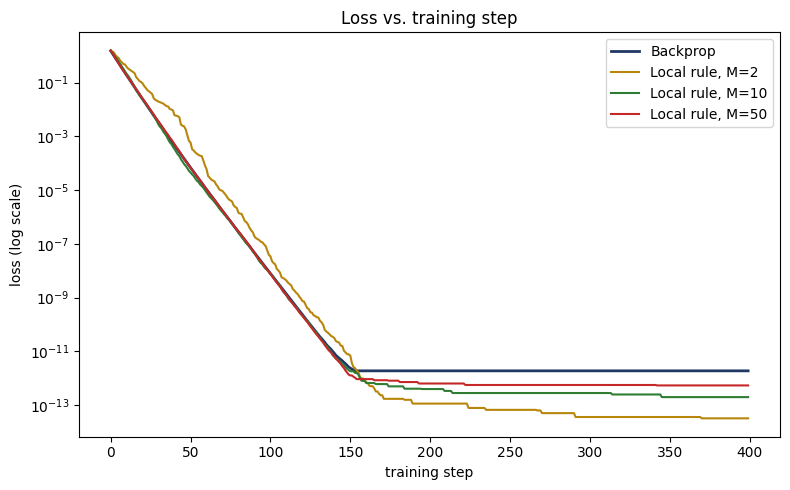

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(bp_losses, label='Backprop', color='#1F3864', linewidth=2)
colors = ['#B8860B', '#2E7D32', '#C62828']
for M, color in zip(M_VALUES, colors):
    ax.plot(local_losses[M], label=f'Local rule, M={M}', color=color, linewidth=1.5)
ax.set_yscale('log')
ax.set_xlabel('training step')
ax.set_ylabel('loss (log scale)')
ax.set_title('Loss vs. training step')
ax.legend()
plt.tight_layout()
plt.show()

## How to read this, once you have your own numbers

- **Accuracy:** compare the final-loss row in Step 3's output. If every method reaches a similarly tiny final loss (as in this notebook's own offline check), that's a real, positive answer to the accuracy question — the local rule isn't leaving quality on the table given enough steps.
- **Sample efficiency:** compare the `steps@target` columns in Step 5. If the local rule's step counts are close to backprop's (not dramatically higher), that means the earlier per-step-cost finding (6.7× at M=10) is close to the FULL story — there's no large additional penalty from needing extra steps on top of that.
- **Total cost, and the M question:** this is Step 6's job. If a smaller M (like 2) reaches similar step-counts to a larger M (like 10 or 50) while costing far less per step, its total-cost ratio to backprop will be noticeably smaller — meaning the earlier "6.7×" framing was pessimistic because it assumed the wrong operating point for M, not because the underlying finding was wrong.
- **If instead a small M needs many more steps to compensate for its noise**, the ratios in Step 6 will show that directly too — in which case M*=10 (or something near it) really is close to the efficient choice, and the earlier framing stands as reported.

Either outcome is a real, useful, reportable finding — send me the Step 4, 5, and 6 text output (just copy-paste it, no screenshot needed) and I'll help you read exactly what it means.